# 911 Emergencies

A US-county would like to know what are the main cases they need to focus on to protect their citizens. They hired you to get that kind of recommandations. In addition they give you a map with all the 911 calls they received over the past years.

1. Import common libraries (including plotly)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import pi
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import  silhouette_score

# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

2. Import the dataset here 👉👉 <a href="https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/DBSCAN/Datasets/911.csv" target="_blank">911.csv</a>

In [48]:
df = pd.read_csv("911.csv")
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


3. The dataset is quite big, take a sample of 10 000 observations

In [49]:
df_sample = df.sample(n=10000, random_state=0)
df_sample.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
600055,40.360688,-75.482317,WALTERS RD & GRAVEL PIKE; UPPER HANOVER; Stat...,18073.0,EMS: HEAD INJURY,2020-01-22 21:02:54,UPPER HANOVER,WALTERS RD & GRAVEL PIKE,1
21520,40.120442,-75.120903,HIGHLAND AVE & WOODLAND RD; ABINGTON; 2016-02-...,19001.0,Traffic: VEHICLE ACCIDENT -,2016-02-02 08:14:02,ABINGTON,HIGHLAND AVE & WOODLAND RD,1
598158,40.164656,-75.286313,SKIPPACK PIKE & CRESTLINE DR; WHITPAIN; Stati...,19422.0,EMS: SYNCOPAL EPISODE,2020-01-18 13:20:29,WHITPAIN,SKIPPACK PIKE & CRESTLINE DR,1
196304,40.072731,-75.155969,CHELTENHAM AVE & 79TH AVE; CHELTENHAM; Statio...,19150.0,EMS: HEMORRHAGING,2017-05-04 14:48:19,CHELTENHAM,CHELTENHAM AVE & 79TH AVE,1
504256,40.097222,-75.376195,PENNSYLVANIA TPKE & ALLENDALE RD OVERPASS; UPP...,NaN,Traffic: DISABLED VEHICLE -,2019-06-04 07:50:36,UPPER MERION,PENNSYLVANIA TPKE & ALLENDALE RD OVERPASS,1


5. Using plotly scatter mapbox, visualize your data points on a map. You should also differentiate colors depending on `title`

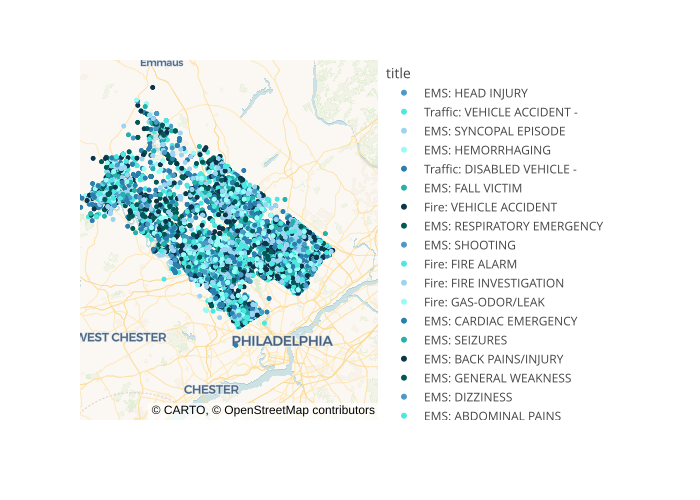

In [50]:
fig = px.scatter_map(data_frame=df_sample, lat="lat", lon="lng", color="title")
fig.show()

6. The dataset is quite big, let's try to use DBSCAN to help us out. First, create a variable `X` that only includes `lat`, `lng` and `title` columns.

In [51]:
X = ['lat', 'lng', 'title']
X = df_sample[X]
X.head()

,lat,lng,title
600055,40.360688,-75.482317,EMS: HEAD INJURY
21520,40.120442,-75.120903,Traffic: VEHICLE ACCIDENT -
598158,40.164656,-75.286313,EMS: SYNCOPAL EPISODE
196304,40.072731,-75.155969,EMS: HEMORRHAGING
504256,40.097222,-75.376195,Traffic: DISABLED VEHICLE -


7. Create dummy variables column `title`.

In [52]:
num

,lat,lng
600055,40.360688,-75.482317
21520,40.120442,-75.120903
598158,40.164656,-75.286313
196304,40.072731,-75.155969
504256,40.097222,-75.376195
...,...,...
322680,40.105308,-75.341987
382229,40.151622,-75.120972
561116,40.133037,-75.408463
70300,40.103900,-75.370750


In [53]:
# Création du pipeline pour les variables quantitatives
numeric_features = [0, 1] # Positions des colonnes quantitatives dans X
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # pour normaliser les variables
])

# Création du pipeline pour les variables catégorielles
categorical_features = [2] # Positions des colonnes catégorielles dans X
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder(drop='first')) # on encode les catégories sous forme de colonnes comportant des 0 et des 1
    ])

# On combine les pipelines dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Preprocessings sur le dataset
print("Preprocessing sur le train set...")
print(X.head())
X = preprocessor.fit_transform(X) # fit_transform !!
print('...Terminé.')
print(X[0:5, :])
print()

Preprocessing sur le train set...
              lat        lng                        title
600055  40.360688 -75.482317             EMS: HEAD INJURY
21520   40.120442 -75.120903  Traffic: VEHICLE ACCIDENT -
598158  40.164656 -75.286313        EMS: SYNCOPAL EPISODE
196304  40.072731 -75.155969            EMS: HEMORRHAGING
504256  40.097222 -75.376195  Traffic: DISABLED VEHICLE -
...Terminé.
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (5, 85)>
  Coords	Values
  (0, 0)	0.9030367896916485
  (0, 1)	-0.11004154567506207
  (0, 29)	1.0
  (1, 0)	-0.18022407382652786
  (1, 1)	0.10947176369941068
  (1, 82)	1.0
  (2, 0)	0.01913326285356729
  (2, 1)	0.009006555384859206
  (2, 48)	1.0
  (3, 0)	-0.3953505949560368
  (3, 1)	0.08817391187273635
  (3, 31)	1.0
  (4, 0)	-0.28492076331826843
  (4, 1)	-0.04558574464212034
  (4, 79)	1.0



8. Let's start using DBSCAN, import the module and fit DBSCAN to your data. You should use `eps=0.2`, `min_samples=100` and `metric="manhattan"` as parameters

In [57]:
db = DBSCAN(eps=0.2, metric="manhattan", min_samples=100)
db.fit(X)

c:\Users\briic\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\briic\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\briic\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\briic\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

DBSCAN(eps=0.2, metric='manhattan', min_samples=100)

9. Find out how many clusters DBSCAN created.

In [63]:
np.unique(db.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

10. Add a new column `"cluster"` to `data_sample` where each observations are going to be the label of the corresponding cluster.

In [69]:
df_sample["cluster"] = db.labels_
colums_drop = ["desc", "zip", "timeStamp", "twp", "addr", "e"]
df_copy = df_sample.drop(colums_drop, axis=1)
df_copy

,lat,lng,title,cluster
600055,40.360688,-75.482317,EMS: HEAD INJURY,-1
21520,40.120442,-75.120903,Traffic: VEHICLE ACCIDENT -,0
598158,40.164656,-75.286313,EMS: SYNCOPAL EPISODE,-1
196304,40.072731,-75.155969,EMS: HEMORRHAGING,-1
504256,40.097222,-75.376195,Traffic: DISABLED VEHICLE -,1
...,...,...,...,...
322680,40.105308,-75.341987,EMS: NAUSEA/VOMITING,-1
382229,40.151622,-75.120972,EMS: UNCONSCIOUS SUBJECT,-1
561116,40.133037,-75.408463,EMS: SUBJECT IN PAIN,6
70300,40.103900,-75.370750,Fire: GAS-ODOR/LEAK,-1


11. Visualize all the clusters on a map except all the ones that DBSCAN considered as outliers.

In [75]:
mask = df_copy["cluster"] != -1
mask

600055    False
21520      True
598158    False
196304    False
504256     True
          ...  
322680    False
382229    False
561116     True
70300     False
28857     False
Name: cluster, Length: 10000, dtype: bool

In [78]:
df_copy_1 = df_copy[mask]
df_copy_1

,lat,lng,title,cluster
21520,40.120442,-75.120903,Traffic: VEHICLE ACCIDENT -,0
504256,40.097222,-75.376195,Traffic: DISABLED VEHICLE -,1
326179,40.139015,-75.212431,EMS: FALL VICTIM,2
20155,40.153754,-75.121604,EMS: RESPIRATORY EMERGENCY,3
37047,40.163557,-75.154074,Traffic: VEHICLE ACCIDENT -,0
...,...,...,...,...
411464,40.215749,-75.545489,Traffic: VEHICLE ACCIDENT -,0
77733,40.079766,-75.401258,Traffic: VEHICLE ACCIDENT -,0
563919,40.156393,-75.192437,Traffic: DISABLED VEHICLE -,1
456941,40.182100,-75.217745,EMS: CARDIAC EMERGENCY,4


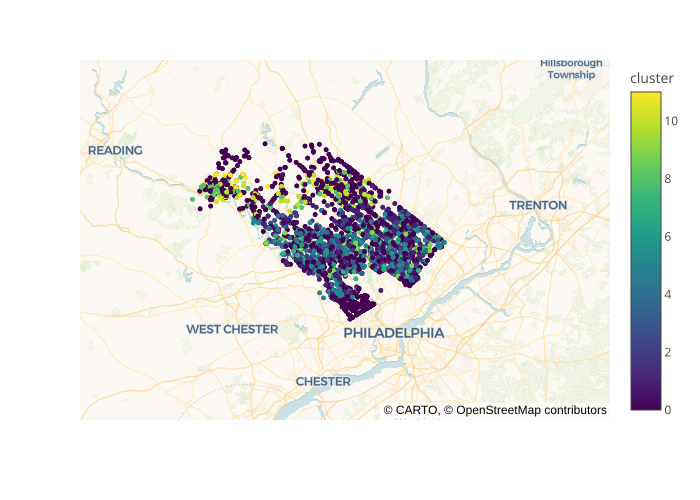

In [79]:
fig2 = px.scatter_map(data_frame=df_copy_1, lat="lat", lon="lng", color="cluster")
fig2.show()

12. Visualize all data points on a map except outliers using plotly. You should have different colors per `title`.

13. What would then be your recommandations for this US county politicians?

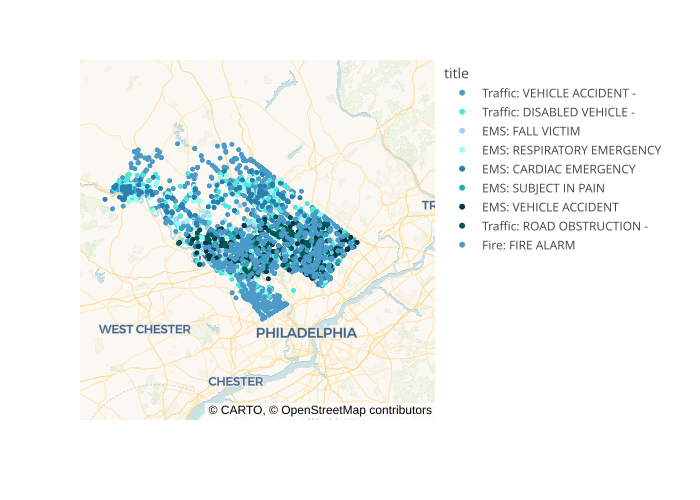

In [80]:
fig3 = px.scatter_map(data_frame=df_copy_1, lat="lat", lon="lng", color="title")
fig3.show()

**The map shows the main topics to focus on and the main areas where this events occur. Therefore these are the areas that politics should focus on.**